# Trimmer ICP Comparison
Compare `MultiStartICP` with and without `ClusteringTrimmer` preprocessing.
Measures convergence of rotation error, translation error, and residuals per iteration,
plus total wall-time across seeds.

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from typing import Any

from feature_extractor import GeometricFeatureExtractor
from matcher import NearestNeighborMatcher
from icp import ICP, MultiStartICP
from experiment_runner import fit_multi_seed
from trimmer import ClusteringTrimmer
from visualization import ErrorMetricsVisualizer, TimeVisualizer

## Configuration

In [2]:
N_SEEDS              = 5
N_POINTS             = 5000
CLOUD_STYLE          = 'muscle-fiber'
NOISE_STD            = 0.0
T_SCALE              = 8.0
DROPOUT_FRACTION     = 0.2

# MultiStartICP
N_STARTS             = 20

# DBSCAN
d = 9 # dimensionality of feature space
DBSCAN_EPS = (2 * d) ** 0.5 * 0.2
DBSCAN_MIN_SAMPLES = int(np.log(N_POINTS))
MIN_CLUSTER_FRACTION = 0.05 

## Setup

In [3]:
matcher = NearestNeighborMatcher(feature_extractor=GeometricFeatureExtractor(k=5))
icp = MultiStartICP(icp=ICP(matcher=matcher, record_history=False), n_starts=N_STARTS)
experiment_kwargs: dict[str, Any] = {"n": N_POINTS, "style": CLOUD_STYLE, "noise_std":NOISE_STD, "t_scale": T_SCALE}
trimmer = ClusteringTrimmer(
    feature_extractor=GeometricFeatureExtractor(k=30),
    clusterer=DBSCAN(eps=DBSCAN_EPS, min_samples=DBSCAN_MIN_SAMPLES),
    min_cluster_fraction=MIN_CLUSTER_FRACTION
)

## Run — baseline vs. trimmed

In [4]:
result_trimmed = fit_multi_seed(icp, trimmer=trimmer, seeds=list(range(N_SEEDS)), experiment_kwargs=experiment_kwargs)
result_trimmed_dropout = fit_multi_seed(icp, dropout_prob=DROPOUT_FRACTION, trimmer=trimmer, seeds=list(range(N_SEEDS)), experiment_kwargs=experiment_kwargs)
result_baseline = fit_multi_seed(icp, seeds=list(range(N_SEEDS)), experiment_kwargs=experiment_kwargs)
result_baseline_dropout = fit_multi_seed(icp, dropout_prob=DROPOUT_FRACTION, seeds=list(range(N_SEEDS)), experiment_kwargs=experiment_kwargs)

Solving 5 seeds: 100%|██████████| 5/5 [02:10<00:00, 26.17s/it]


## Results — convergence and wall-time

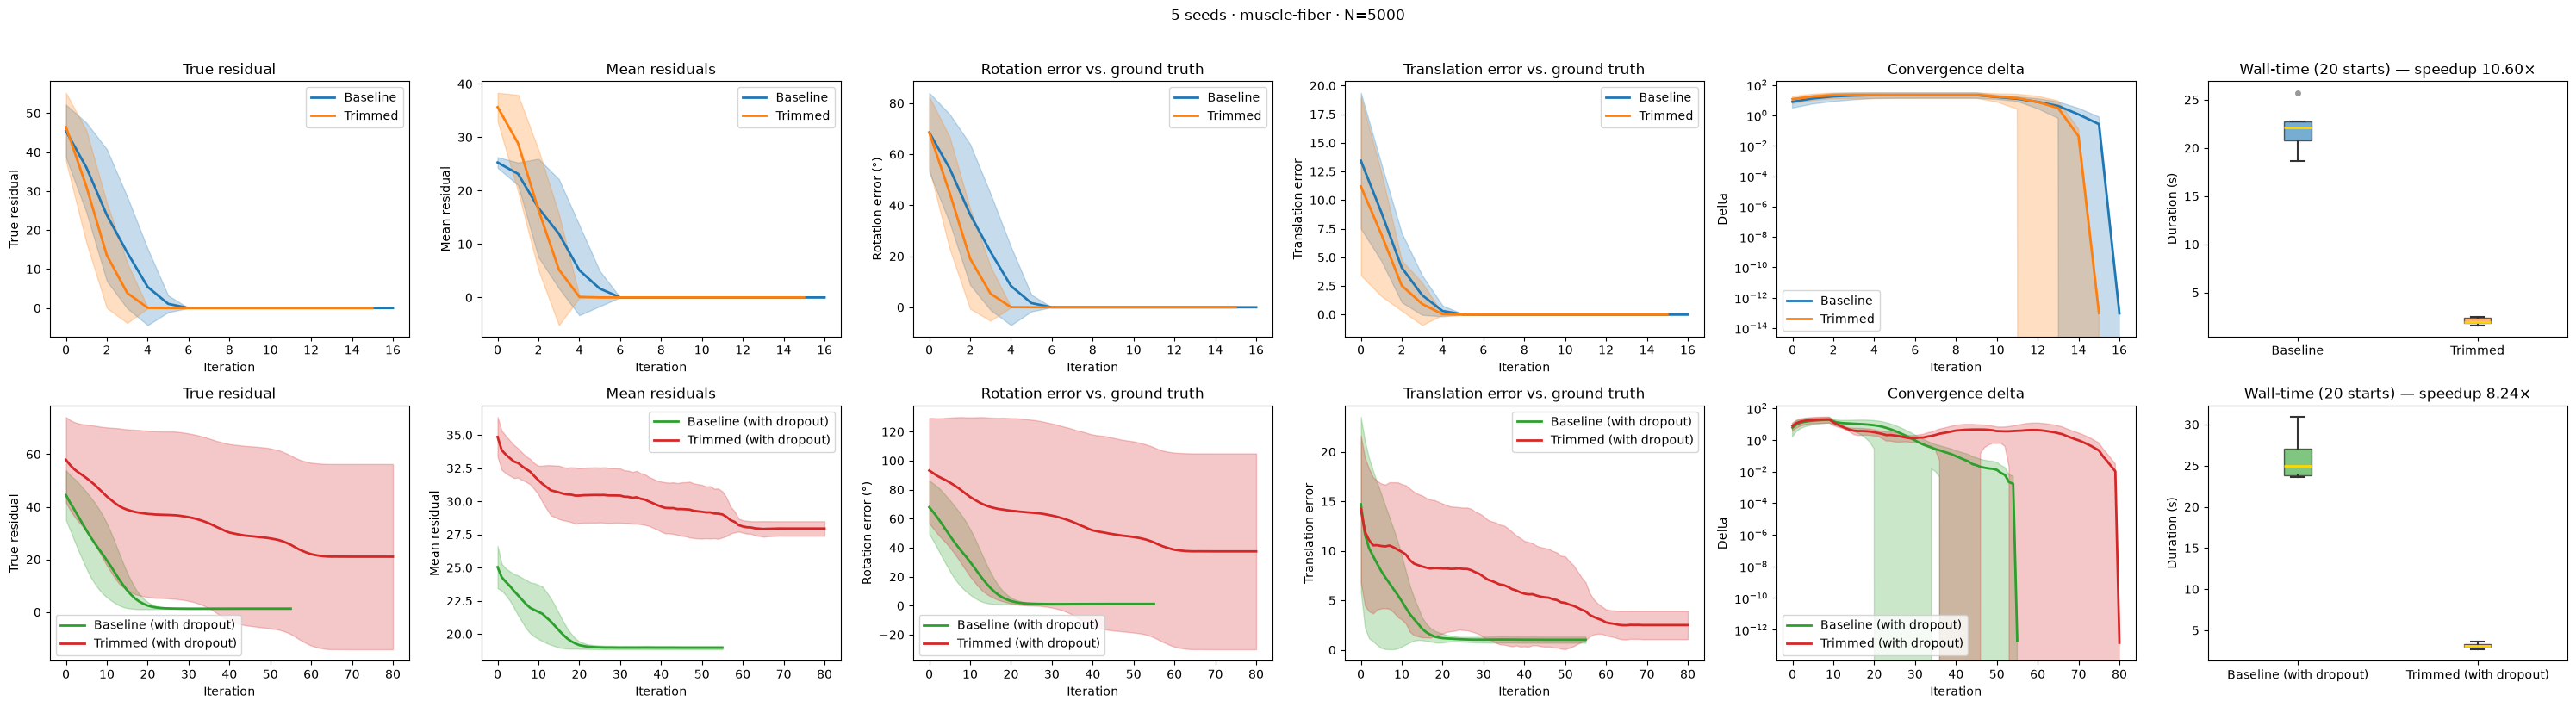

In [10]:
methods             = [result_baseline.results, result_trimmed.results]
methods_dropout     = [result_baseline_dropout.results, result_trimmed_dropout.results]
experiments         = [result_baseline.experiments, result_trimmed.experiments]
experiments_dropout = [result_baseline_dropout.experiments, result_trimmed_dropout.experiments]
labels              = ['Baseline', 'Trimmed']
labels_dropout      = ['Baseline (with dropout)', 'Trimmed (with dropout)']
colors              = ['tab:blue', 'tab:orange']
colors_dropout      = ['tab:green', 'tab:red']

fig, axes = plt.subplots(2, 6, figsize=(30, 8))

ErrorMetricsVisualizer.plot_true_residual_errors_per_iteration(axes[0, 0], methods, experiments, labels, colors)
ErrorMetricsVisualizer.plot_residual_errors_per_iteration(axes[0, 1], methods, labels, colors)
ErrorMetricsVisualizer.plot_rot_error_per_iterations(axes[0, 2], methods, experiments, labels, colors)
ErrorMetricsVisualizer.plot_translation_error_per_iterations(axes[0, 3], methods, experiments, labels, colors)
ErrorMetricsVisualizer.plot_delta_per_iterations(axes[0, 4], methods, labels, colors)

speedup = np.mean(result_baseline.durations_s) / np.mean(result_trimmed.durations_s)
TimeVisualizer.plot_duration_distribution(
    axes[0, 5],
    durations_per_method=[result_baseline.durations_s, result_trimmed.durations_s],
    method_labels=labels,
    colors=colors,
)
axes[0, 5].set_title(f'Wall-time ({N_STARTS} starts) — speedup {speedup:.2f}×')

ErrorMetricsVisualizer.plot_true_residual_errors_per_iteration(axes[1, 0], methods_dropout, experiments, labels_dropout, colors_dropout)
ErrorMetricsVisualizer.plot_residual_errors_per_iteration(axes[1, 1], methods_dropout, labels_dropout, colors_dropout)
ErrorMetricsVisualizer.plot_rot_error_per_iterations(axes[1, 2], methods_dropout, experiments_dropout, labels_dropout, colors_dropout)
ErrorMetricsVisualizer.plot_translation_error_per_iterations(axes[1, 3], methods_dropout, experiments_dropout, labels_dropout, colors_dropout)
ErrorMetricsVisualizer.plot_delta_per_iterations(axes[1, 4], methods_dropout, labels_dropout, colors_dropout)
speedup_dropout = np.mean(result_baseline_dropout.durations_s) / np.mean(result_trimmed_dropout.durations_s)
TimeVisualizer.plot_duration_distribution(
    axes[1, 5],
    durations_per_method=[result_baseline_dropout.durations_s, result_trimmed_dropout.durations_s],
    method_labels=labels_dropout,
    colors=colors_dropout,
)
axes[1, 5].set_title(f'Wall-time ({N_STARTS} starts) — speedup {speedup_dropout:.2f}×') 

fig.suptitle(f'{N_SEEDS} seeds · {CLOUD_STYLE} · N={N_POINTS}', y=1.02)
plt.tight_layout()
plt.show()